# Quartic Double-Well Potential

This notebook studies the one-dimensional **quartic double-well potential**

$$
V(x) = ax^4 - bx^2
$$
which is a simple model for **tunnelling** between two classically allowed regions.

When $a > 0$ and $b > 0$, the $x^4$ term keeps the particle bound, while the $-bx^2$ term creates two minima.
This gives a potential with **two wells** separated by a barrier near \(x=0\).

Our goal is to:
- build the Hamiltonian numerically,
- solve for the lowest eigenvalues and eigenfunctions,
- plot the wavefunctions on top of the potential, and
- understand how the lowest two states are related to tunnelling.
- understand the effects on a charged particle in an external field
$$
V(x) = ax^4 - bx^2 + cx
$$



## Schrödinger Equation

In atomic units ($\hbar = m = 1$), the Hamiltonian is

$$
\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + V(x),
$$

with

$$
V(x) = ax^4 - bx^2.
$$

We will solve this equation on a grid using a **finite-difference approximation** for the second derivative.

For a grid spacing $\Delta x$, the kinetic-energy operator is approximated by

$$
-\frac{1}{2}\frac{d^2\psi}{dx^2}
\approx
-\frac{1}{2}\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{(\Delta x)^2}.
$$

This turns the Schrödinger equation into a matrix eigenvalue problem.

## Why this is a double well

To locate the stationary points of the potential, we differentiate:

$$
\frac{dV}{dx} = 4ax^3 - 2bx = 2x(2ax^2 - b).
$$

So the stationary points are at

$$
x = 0, \qquad x = \pm \sqrt{\frac{b}{2a}}.
$$

For $a > 0$ and $b > 0$:

- $x = 0$ is the **barrier top**  
- $x = \pm \sqrt{\frac{b}{2a}}$ are the **two minima**

The depth and separation of the wells depend on the values of $a$ and $b$.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

plt.rcParams["figure.dpi"] = 130

In [42]:
def quartic_potential(x, a=0.02, b=1.0):
    """Return the quartic double-well potential V(x) = a x^4 - b x^2."""
    return a * x**4 - b * x**2

def kinetic_energy_matrix(x):
    """Construct the finite-difference kinetic-energy matrix."""
    dx = x[1] - x[0]
    n = len(x)
    main = np.full(n, 1.0 / dx**2)
    off = np.full(n - 1, -0.5 / dx**2)
    T = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)
    return T

def hamiltonian_matrix(x, a=0.02, b=1.0):
    """Construct H = T + V on the grid x."""
    T = kinetic_energy_matrix(x)
    V = np.diag(quartic_potential(x, a=a, b=b))
    return T + V

def normalize_wavefunction(psi, x):
    """Normalize a wavefunction on the grid x."""
    norm = np.sqrt(np.trapezoid(np.abs(psi)**2, x))
    return psi / norm

def solve_double_well(x, a=0.02, b=1.0, nstates=6):
    """Solve for the lowest-energy eigenstates of the quartic double well."""
    H = hamiltonian_matrix(x, a=a, b=b)
    eigvals, eigvecs = eigh(H)

    eigvals = eigvals[:nstates]
    eigvecs = eigvecs[:, :nstates]

    for i in range(nstates):
        eigvecs[:, i] = normalize_wavefunction(eigvecs[:, i], x)

    return eigvals, eigvecs

In [43]:
# Define a grid and solve the problem for one choice of parameters.
x = np.linspace(-8, 8, 800)

a = 0.02
b = 1.0

energies, wavefunctions = solve_double_well(x, a=a, b=b, nstates=6)

print("Lowest six energies:")
for i, E in enumerate(energies):
    print(f"n = {i}: E = {E:.6f}")

Lowest six energies:
n = 0: E = -11.510286
n = 1: E = -11.510286
n = 2: E = -9.573803
n = 3: E = -9.573803
n = 4: E = -7.706949
n = 5: E = -7.706949


# Physical Interpretation: Connection to Real Systems

The double-well potential models real systems:


*   Chemical reactions: wells = reactant & product

*   Electron transfer: wells = two sites

*   Proton transfer: tunneling in hydrogen bonds

The barrier represents activation energy.



## Plotting the potential and eigenfunctions

To compare the shapes of the wavefunctions with the potential,
the wavefunctions was shifted upward by their eigenenergies.



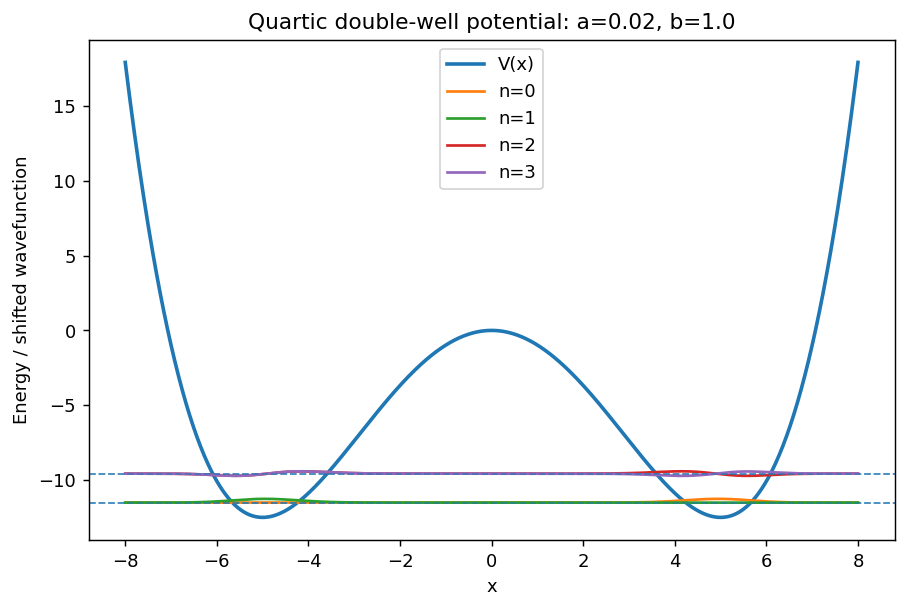

In [44]:
def plot_states(x, energies, wavefunctions, a=0.02, b=1.0, nplot=4, scale=0.28):
    """Plot the potential and the lowest few eigenfunctions."""
    Vx = quartic_potential(x, a=a, b=b)

    plt.figure(figsize=(8, 5))
    plt.plot(x, Vx, lw=2, label="V(x)")

    for n in range(nplot):
        psi = wavefunctions[:, n]
        plt.plot(x, energies[n] + scale * psi, label=f"n={n}")
        plt.axhline(energies[n], ls="--", lw=1, alpha=0.6)

    plt.xlabel("x")
    plt.ylabel("Energy / shifted wavefunction")
    plt.title(f"Quartic double-well potential: a={a}, b={b}")
    plt.legend()
    plt.show()

plot_states(x, energies, wavefunctions, a=a, b=b, nplot=4)

## Probability densities

The quantity $|\psi(x)|^2$ gives the probability density.
For a symmetric double well:

- the **ground state** is symmetric,
- the **first excited state** is antisymmetric,
- the two lowest energies are often very close together.

That small energy difference is a signature of **quantum tunnelling** through the central barrier.

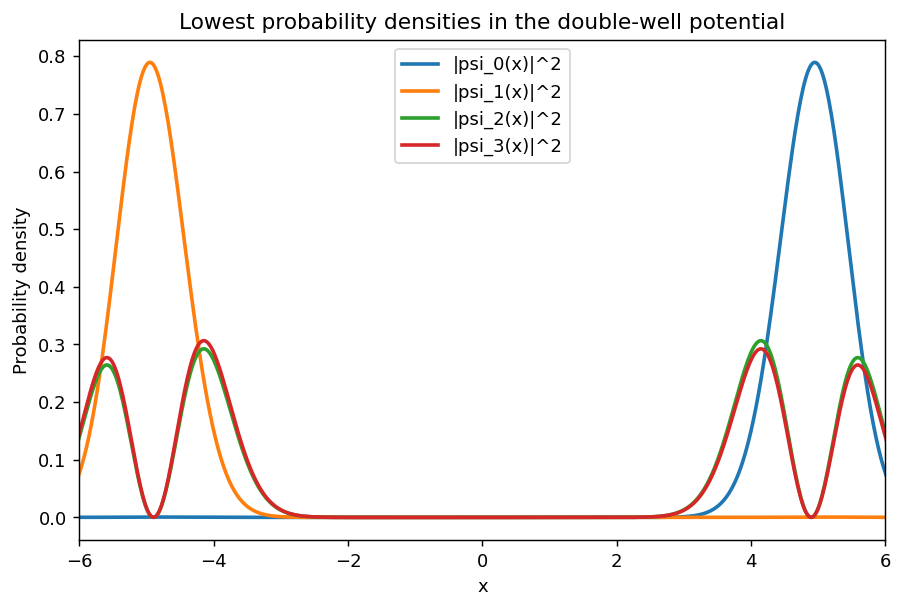

Energy splitting between the two lowest states: ΔE = 0.000000


In [45]:
plt.figure(figsize=(8, 5))
for n in range(4):
    plt.plot(x, np.abs(wavefunctions[:, n])**2, lw=2, label=f"|psi_{n}(x)|^2")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lowest probability densities in the double-well potential")
plt.xlim(-6, 6)
plt.legend()
plt.show()

print(f"Energy splitting between the two lowest states: ΔE = {energies[1] - energies[0]:.6f}")

## Changing the barrier shape

The parameter $a$ controls how strongly the particle is confined at large $|x|$,  
while $b$ helps create the two minima.

A useful question is: **what happens to the lowest two energies when the barrier changes?**

Below, we vary $b$ while keeping $a$ fixed.

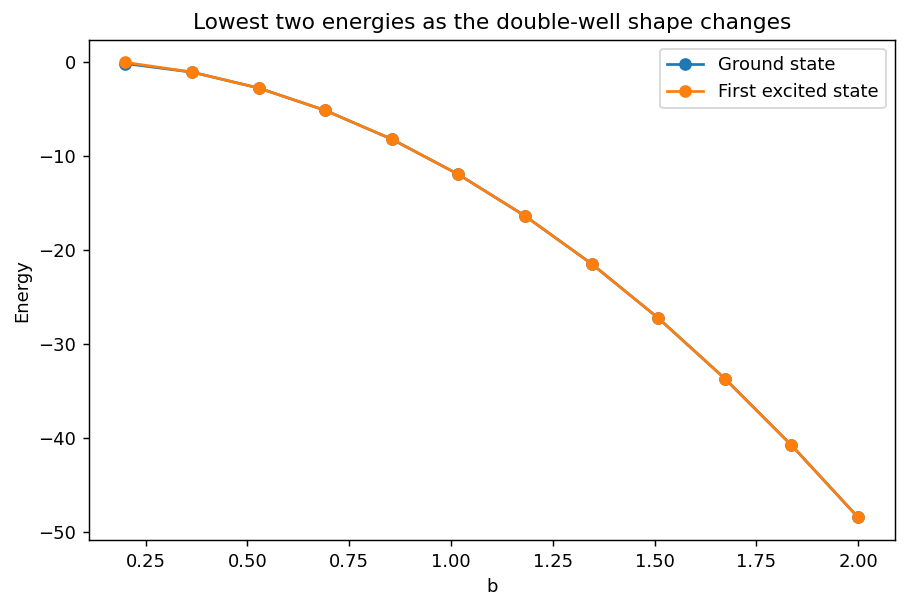

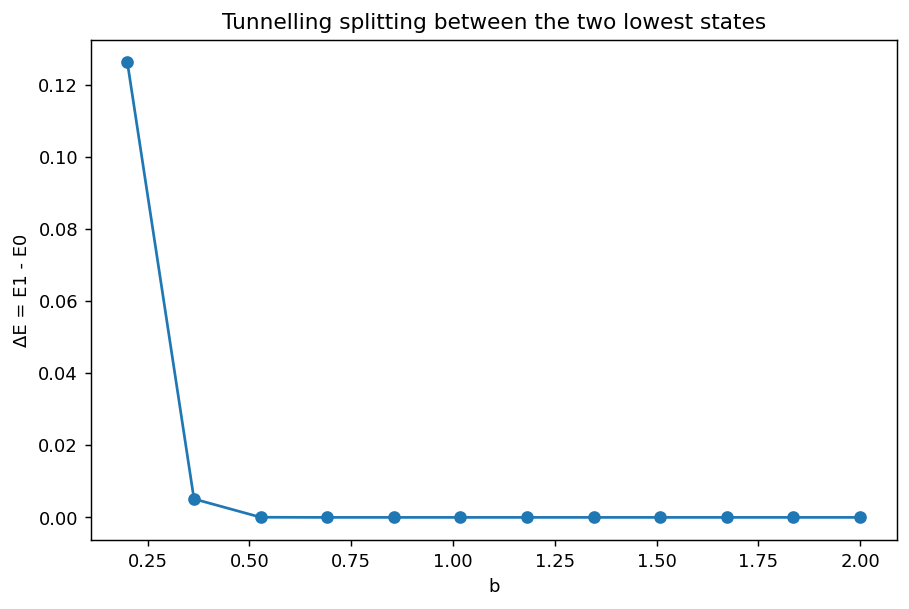

In [46]:
def compute_lowest_two_energies(x, a=0.02, b_values=None):
    if b_values is None:
        b_values = np.linspace(0.2, 2.0, 10)

    E0 = []
    E1 = []
    split = []

    for b in b_values:
        energies, _ = solve_double_well(x, a=a, b=b, nstates=2)
        E0.append(energies[0])
        E1.append(energies[1])
        split.append(energies[1] - energies[0])

    return np.array(b_values), np.array(E0), np.array(E1), np.array(split)

b_values, E0, E1, split = compute_lowest_two_energies(x, a=0.02, b_values=np.linspace(0.2, 2.0, 12))

plt.figure(figsize=(8, 5))
plt.plot(b_values, E0, "o-", label="Ground state")
plt.plot(b_values, E1, "o-", label="First excited state")
plt.xlabel("b")
plt.ylabel("Energy")
plt.title("Lowest two energies as the double-well shape changes")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(b_values, split, "o-")
plt.xlabel("b")
plt.ylabel("ΔE = E1 - E0")
plt.title("Tunnelling splitting between the two lowest states")
plt.show()

##  Tilted Double-Well Potential (Charged Particle)

In this section, we extend the symmetric quartic double-well potential by adding a linear term to model a charged particle in an external electric field:

$$
V(x) = ax^4 - bx^2 + cx
$$

The first two terms create the symmetric double-well potential, while the linear term $$cx$$ introduces a tilt. This represents the interaction of a charged particle with an electric field where $$c \sim qE$$ ,breaking the symmetry and making one well deeper than the other.




###  Hamiltonian Construction

The Hamiltonian is constructed as:

$$
\hat{H} = -\frac{1}{2}\frac{d^2}{dx^2} + V(x)
$$

- The kinetic energy is approximated using a finite-difference method, resulting in a tridiagonal matrix.
- The tilted potential is added as a diagonal matrix.

###  Solving the System

The Hamiltonian matrix is diagonalized to obtain:
- **Eigenvalues** → energy levels  
- **Eigenvectors** → wavefunctions  

The wavefunctions are normalized so that:

$$
\int |\psi(x)|^2 dx = 1
$$

In [50]:
# Tilted double-well potential (charged particle in electric field)


def tilted_potential(x, a=0.02, b=1.0, c=0.05):
    """Quartic double-well with a linear tilt term."""
    return a*x**4 - b*x**2 + c*x


def solve_tilted_double_well(x, a=0.02, b=1.0, c=0.05, nstates=6):
    """Solve tilted system using same kinetic operator."""

    # Kinetic part (same as before)
    T = kinetic_energy_matrix(x)

    # NEW potential (tilted)
    V = np.diag(tilted_potential(x, a=a, b=b, c=c))

    # Hamiltonian
    H = T + V

    # Solve eigenvalue problem
    eigvals, eigvecs = eigh(H)

    # Keep lowest states
    eigvals = eigvals[:nstates]
    eigvecs = eigvecs[:, :nstates]

    # Normalize
    for i in range(nstates):
        eigvecs[:, i] = normalize_wavefunction(eigvecs[:, i], x)

    return eigvals, eigvecs

Plot: Tilted Potential and Wavefunctions

The plot shows the tilted double-well potential along with the lowest energy states.

- The potential is no longer symmetric, and one well is deeper.
- The wavefunctions are shifted toward the deeper well, indicating higher probability in that region.
- Energy levels are no longer nearly degenerate due to broken symmetry.
- Tunneling still occurs, but it becomes asymmetric.
- The wavefunctions become more localized in the deeper well because the particle minimizes its energy by occupying the lower-energy region.

This demonstrates how an external electric field modifies the system by altering both the energy levels and the spatial distribution of the particle.

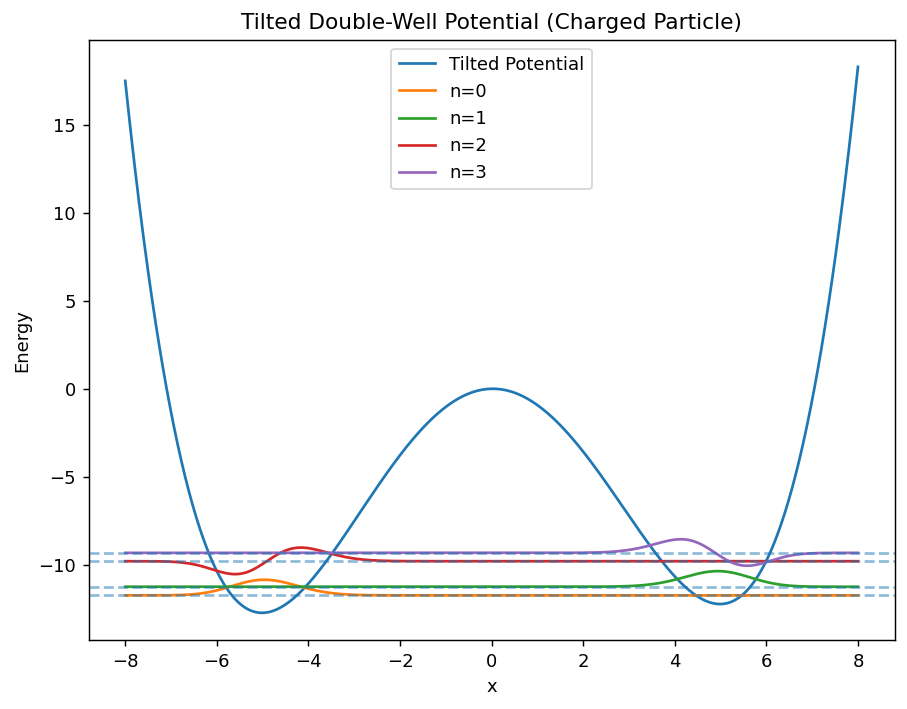

In [55]:
# Plot tilted potential and wavefunctions


x = np.linspace(-8, 8, 800)

eigvals, eigvecs = solve_tilted(x, c=0.05)

plt.figure(figsize=(8,6))

# Plot potential
plt.plot(x, tilted_potential(x, c=0.05), label="Tilted Potential")

# Plot wavefunctions
for i in range(len(eigvals)):
    plt.plot(x, eigvecs[:, i] + eigvals[i], label=f"n={i}")

# Energy levels
for E in eigvals:
    plt.axhline(E, linestyle='--', alpha=0.5)

plt.xlabel("x")
plt.ylabel("Energy")
plt.title("Tilted Double-Well Potential (Charged Particle)")
plt.legend()
plt.show()

## Discussion

This notebook shows the main quantum features of a double-well system:

1. The quartic potential $V(x) = ax^4 - bx^2$ produces two minima for $a > 0$ and $b > 0$.
2. The Schrödinger equation can be solved numerically using a finite-difference Hamiltonian.
3. The two lowest states are close in energy because the particle can tunnel through the barrier.
4. As the barrier changes, the splitting $\Delta E = E_1 - E_0$ also changes.
5. Physically, the lowest two stationary states are spread over both wells, even though classically one might expect the particle to stay in just one well.
6. Introduced a linear term to the potential, $$V(x) = ax^4 - bx^2 + cx $$, to represent a charged particle in an external electric field. This breaks the symmetry of the system and makes one well deeper than the other.

As a result, the wavefunctions become localized toward the deeper well, and the energy levels are no longer nearly degenerate. Tunneling still occurs, but it becomes asymmetric, with the particle having a higher probability of being found in the lower-energy well.

Such models are important for understanding real physical systems, including electron transfer and chemical reactions where one state is energetically favored.

In the symmetric case, the wavefunctions are distributed equally across both wells, while in the tilted case they become localized in the deeper well due to symmetry breaking.

Overall, this notebook highlights fundamental quantum effects such as tunneling, superposition, symmetry breaking, and energy splitting in systems with multiple stable configurations.

